**Install and import the Libraries**




In [2]:
# Install yfinance
!pip install yfinance --quiet

In [3]:
import yfinance as yf       # for downloading stock price data
import pandas as pd         # for working with tables of data
import numpy as np          # for math operations on arrays
import matplotlib.pyplot as plt  # for plotting charts
import seaborn as sns       # makes prettier charts (built on matplotlib)

# This makes charts appear inline in the notebook
%matplotlib inline

# Set a clean style for all plots
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

**Choose your Portfolio**


In [4]:
# Define our portfolio: 15 stocks across sectors
# Tickers are the stock symbols Yahoo Finance uses
tickers = [
    'AAPL',   # Apple - Tech
    'MSFT',   # Microsoft - Tech
    'GOOGL',  # Alphabet - Tech
    'AMZN',   # Amazon - Consumer/Tech
    'NVDA',   # Nvidia - Semiconductors
    'JPM',    # JPMorgan - Financials
    'BAC',    # Bank of America - Financials
    'XOM',    # Exxon Mobil - Energy
    'CVX',    # Chevron - Energy
    'JNJ',    # Johnson & Johnson - Healthcare
    'PFE',    # Pfizer - Healthcare
    'WMT',    # Walmart - Consumer Staples
    'PG',     # Procter & Gamble - Consumer Staples
    'KO',     # Coca-Cola - Consumer Staples
    'BA'      # Boeing - Industrials
]

# Date range: 5 years of data ending today
start_date = '2021-01-01'
end_date = '2026-01-01'

print(f"Portfolio: {len(tickers)} stocks")
print(f"Period: {start_date} to {end_date}")

Portfolio: 15 stocks
Period: 2021-01-01 to 2026-01-01


**Download the price data**

In [5]:
# Download daily price data for all tickers at once
data = yf.download(tickers, start=start_date, end=end_date)

# Show what we got
print("Shape of data:", data.shape)
print("\nFirst few rows:")
data.head()

/tmp/ipykernel_9793/644398025.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  15 of 15 completed

Shape of data: (1255, 75)

First few rows:


Price            Close                                                \
Ticker            AAPL        AMZN          BA        BAC        CVX   
Date                                                                   
2021-01-04  125.740837  159.331497  202.720001  26.464045  67.829147   
2021-01-05  127.295464  160.925507  211.630005  26.666735  69.662804   
2021-01-06  123.010521  156.919006  211.029999  28.332306  71.904823   
2021-01-07  127.208061  158.108002  212.710007  28.957994  72.241119   
2021-01-08  128.305984  159.134995  209.899994  28.667179  72.929749   

Price                                                                 ...  \
Ticker          GOOGL         JNJ         JPM         KO        MSFT  ...   
Date                                                                  ...   
2021-01-04  85.599030  135.059662  109.491570  45.081966  208.406540  ...   
2021-01-05  86.289322  136.647568  110.087357  44.586384  208.607590  ...   
2021-01-06  85.437866  137.933456  115.256577  43.167953  203.198532  ...   
2021-01-07  87.989784  138.399475  119.041512  42.689457  208.980942  ...   
2021-01-08  89.154640  138.114655  119.172943  43.646458  210.254196  ...   

Price         Volume                                                     \
Ticker         GOOGL       JNJ       JPM        KO      MSFT       NVDA   
Date                                                                      
2021-01-04  37324000  11765900  16819900  25611100  37130100  560640000   
2021-01-05  20360000   9602300  13731200  20323800  23823000  322760000   
2021-01-06  46588000   8230100  24909100  38724500  35930700  580424000   
2021-01-07  41936000   7747200  21940400  53225700  27694500  461480000   
2021-01-08  35484000   8228900  12035100  29674000  22956200  292528000   

Price                                               
Ticker           PFE        PG       WMT       XOM  
Date                                                
2021-01-04  33565700   8330900  32182200  27764700  
2021-01-05  29909400   6856400  26498100  44035100  
2021-01-06  34962500  10578000  21918900  36484800  
2021-01-07  27809500   7355400  20538000  29528100  
2021-01-08  33462400   7448500  24478200  28628200  

[5 rows x 75 columns]

In [6]:
# Extract just the Adjusted Close prices
prices = data['Close']  # Newer yfinance versions auto-adjust by default

# If your version returns 'Adj Close', use this instead:
# prices = data['Adj Close']

print("Prices DataFrame:")
print(prices.head())
print(f"\nShape: {prices.shape}")  # (trading_days, num_stocks)

Prices DataFrame:
Ticker            AAPL        AMZN          BA        BAC        CVX  \
Date                                                                   
2021-01-04  125.740837  159.331497  202.720001  26.464045  67.829147   
2021-01-05  127.295464  160.925507  211.630005  26.666735  69.662804   
2021-01-06  123.010521  156.919006  211.029999  28.332306  71.904823   
2021-01-07  127.208061  158.108002  212.710007  28.957994  72.241119   
2021-01-08  128.305984  159.134995  209.899994  28.667179  72.929749   

Ticker          GOOGL         JNJ         JPM         KO        MSFT  \
Date                                                                   
2021-01-04  85.599030  135.059662  109.491570  45.081966  208.406540   
2021-01-05  86.289322  136.647568  110.087357  44.586384  208.607590   
2021-01-06  85.437866  137.933456  115.256577  43.167953  203.198532   
2021-01-07  87.989784  138.399475  119.041512  42.689457  208.980942   
2021-01-08  89.154640  138.114655  119.172943

**Defensive check**

In [7]:
# Check for missing data
print("Missing values per stock:")
print(prices.isna().sum())

# Drop any rows with missing data (clean conservative approach)
prices = prices.dropna()
print(f"\nClean data shape: {prices.shape}")

Missing values per stock:
Ticker
AAPL     0
AMZN     0
BA       0
BAC      0
CVX      0
GOOGL    0
JNJ      0
JPM      0
KO       0
MSFT     0
NVDA     0
PFE      0
PG       0
WMT      0
XOM      0
dtype: int64

Clean data shape: (1255, 15)


**Calculate Daily Returns**

In [8]:
# Daily returns: percentage change from yesterday's close to today's close
daily_returns = prices.pct_change().dropna()

print("Daily returns (first 5 rows):")
print(daily_returns.head())

Daily returns (first 5 rows):
Ticker          AAPL      AMZN        BA       BAC       CVX     GOOGL  \
Date                                                                     
2021-01-05  0.012364  0.010004  0.043952  0.007659  0.027033  0.008064   
2021-01-06 -0.033661 -0.024897 -0.002835  0.062459  0.032184 -0.009867   
2021-01-07  0.034123  0.007577  0.007961  0.022084  0.004677  0.029869   
2021-01-08  0.008631  0.006496 -0.013211 -0.010043  0.009532  0.013239   
2021-01-11 -0.023249 -0.021519 -0.014817  0.016600  0.005709 -0.023106   

Ticker           JNJ       JPM        KO      MSFT      NVDA       PFE  \
Date                                                                     
2021-01-05  0.011757  0.005441 -0.010993  0.000965  0.022210  0.010323   
2021-01-06  0.009410  0.046956 -0.031813 -0.025929 -0.058953 -0.008604   
2021-01-07  0.003379  0.032839 -0.011085  0.028457  0.057830  0.005153   
2021-01-08 -0.002058  0.001104  0.022418  0.006093 -0.005040  0.001889   
2021-01

**Define Portfolio Weights**

In [9]:
# Equal-weighted portfolio: each stock gets 1/15 of the money
num_stocks = len(tickers)
weights = np.array([1/num_stocks] * num_stocks)

print(f"Each stock weight: {weights[0]:.4f} ({weights[0]*100:.2f}%)")
print(f"Total weights sum to: {weights.sum():.4f}")  # Must equal 1.0

Each stock weight: 0.0667 (6.67%)
Total weights sum to: 1.0000


**Portfolio Returns**

In [10]:
# Portfolio return for any day = weighted sum of each stock's return that day
portfolio_returns = daily_returns.dot(weights)

print("Portfolio daily returns (first 5):")
print(portfolio_returns.head())
print(f"\nMean daily return: {portfolio_returns.mean():.6f}")
print(f"That's an annualised return of: {portfolio_returns.mean() * 252 * 100:.2f}%")

Portfolio daily returns (first 5):
Date
2021-01-05    0.013202
2021-01-06   -0.000218
2021-01-07    0.014753
2021-01-08    0.003307
2021-01-11   -0.000352
dtype: float64

Mean daily return: 0.000781
That's an annualised return of: 19.67%


**Volatility (risk)**

In [11]:
# Daily volatility = standard deviation of daily returns
daily_volatility = portfolio_returns.std()

# Annualise: multiply by sqrt(252), NOT 252
annual_volatility = daily_volatility * np.sqrt(252)

print(f"Daily volatility: {daily_volatility:.4f} ({daily_volatility*100:.2f}%)")
print(f"Annual volatility: {annual_volatility:.4f} ({annual_volatility*100:.2f}%)")

Daily volatility: 0.0099 (0.99%)
Annual volatility: 0.1579 (15.79%)


**Sharpe Ratio**

In [12]:
# Sharpe ratio: return per unit of risk, above the risk-free rate
# Risk-free rate: 10-year US Treasury yield, approx 4.3% as of 2026
risk_free_rate = 0.043

annual_return = portfolio_returns.mean() * 252
sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

print(f"Annual return: {annual_return*100:.2f}%")
print(f"Annual volatility: {annual_volatility*100:.2f}%")
print(f"Risk-free rate: {risk_free_rate*100:.2f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.3f}")

Annual return: 19.67%
Annual volatility: 15.79%
Risk-free rate: 4.30%
Sharpe Ratio: 0.973


**Maximum Drawdown**

In [13]:
# Cumulative returns: what $1 invested at the start would be worth over time
cumulative_returns = (1 + portfolio_returns).cumprod()

# Running maximum: the highest cumulative value seen up to each point
running_max = cumulative_returns.cummax()

# Drawdown: how far below the peak we are at each point, in percent
drawdown = (cumulative_returns - running_max) / running_max

max_drawdown = drawdown.min()  # most negative value = worst drawdown

print(f"Maximum Drawdown: {max_drawdown*100:.2f}%")
print(f"Date of worst drawdown: {drawdown.idxmin().date()}")

Maximum Drawdown: -21.97%
Date of worst drawdown: 2022-09-30


**Correlation matrix**

In [14]:
# Correlation matrix: how each pair of stocks moves together
correlation_matrix = daily_returns.corr()

print("Correlation matrix:")
print(correlation_matrix.round(2))

Correlation matrix:
Ticker  AAPL  AMZN    BA   BAC   CVX  GOOGL   JNJ   JPM    KO  MSFT  NVDA  \
Ticker                                                                      
AAPL    1.00  0.56  0.38  0.34  0.24   0.58  0.15  0.35  0.27  0.63  0.52   
AMZN    0.56  1.00  0.37  0.34  0.18   0.62  0.01  0.34  0.11  0.65  0.56   
BA      0.38  0.37  1.00  0.43  0.30   0.31  0.06  0.42  0.14  0.31  0.34   
BAC     0.34  0.34  0.43  1.00  0.44   0.31  0.18  0.81  0.21  0.29  0.28   
CVX     0.24  0.18  0.30  0.44  1.00   0.18  0.16  0.40  0.17  0.15  0.15   
GOOGL   0.58  0.62  0.31  0.31  0.18   1.00  0.07  0.32  0.14  0.64  0.53   
JNJ     0.15  0.01  0.06  0.18  0.16   0.07  1.00  0.21  0.45  0.08 -0.10   
JPM     0.35  0.34  0.42  0.81  0.40   0.32  0.21  1.00  0.23  0.31  0.32   
KO      0.27  0.11  0.14  0.21  0.17   0.14  0.45  0.23  1.00  0.21  0.01   
MSFT    0.63  0.65  0.31  0.29  0.15   0.64  0.08  0.31  0.21  1.00  0.63   
NVDA    0.52  0.56  0.34  0.28  0.15   0.53 -0.10  0.32 

**Risk Decomposition**

In [15]:
# Annualised covariance matrix
cov_matrix = daily_returns.cov() * 252

# Portfolio variance = w' · Σ · w (matrix maths)
portfolio_variance = weights.T @ cov_matrix @ weights
portfolio_vol = np.sqrt(portfolio_variance)

# Marginal contribution to risk: how much each stock's small weight increase
# would increase portfolio risk
marginal_contrib = cov_matrix @ weights

# Component contribution: weight × marginal contribution
# This tells you each stock's actual share of total portfolio risk
component_contrib = weights * marginal_contrib

# As percentages
risk_contribution_pct = component_contrib / portfolio_variance * 100

risk_df = pd.DataFrame({
    'Weight (%)': weights * 100,
    'Risk Contribution (%)': risk_contribution_pct
}, index=tickers).sort_values('Risk Contribution (%)', ascending=False)

print("Risk Decomposition:")
print(risk_df.round(2))

Risk Decomposition:
       Weight (%)  Risk Contribution (%)
NVDA         6.67                  14.41
AMZN         6.67                  10.41
BA           6.67                   9.52
GOOGL        6.67                   8.93
AAPL         6.67                   8.62
MSFT         6.67                   7.74
BAC          6.67                   7.58
JPM          6.67                   6.83
CVX          6.67                   5.62
XOM          6.67                   5.33
PFE          6.67                   3.80
WMT          6.67                   3.78
KO           6.67                   2.69
PG           6.67                   2.61
JNJ          6.67                   2.12


**The 4-panel dashboard**

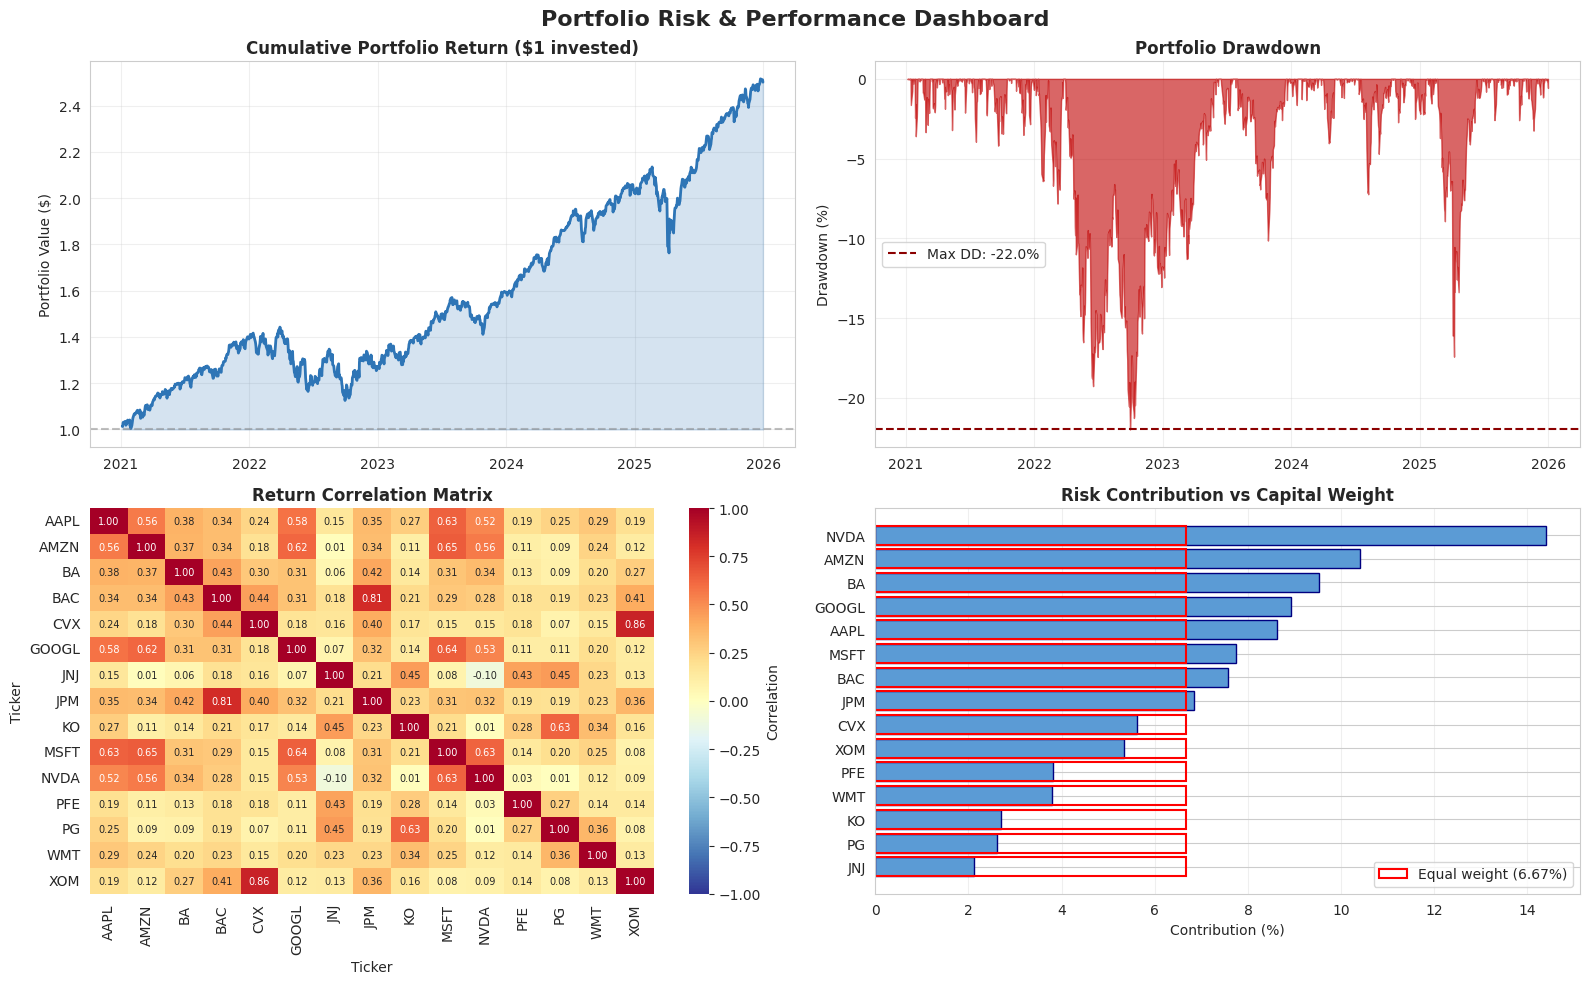

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Portfolio Risk & Performance Dashboard', fontsize=16, fontweight='bold')

# ---- Panel 1 (top-left): Cumulative returns ----
axes[0, 0].plot(cumulative_returns.index, cumulative_returns.values,
                color='#2E75B6', linewidth=2)
axes[0, 0].fill_between(cumulative_returns.index, 1, cumulative_returns.values,
                        alpha=0.2, color='#2E75B6')
axes[0, 0].axhline(y=1, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Cumulative Portfolio Return ($1 invested)', fontweight='bold')
axes[0, 0].set_ylabel('Portfolio Value ($)')
axes[0, 0].grid(True, alpha=0.3)

# ---- Panel 2 (top-right): Drawdown ----
axes[0, 1].fill_between(drawdown.index, drawdown.values * 100, 0,
                        color='#C00000', alpha=0.6)
axes[0, 1].axhline(y=max_drawdown*100, color='darkred', linestyle='--',
                   label=f'Max DD: {max_drawdown*100:.1f}%')
axes[0, 1].set_title('Portfolio Drawdown', fontweight='bold')
axes[0, 1].set_ylabel('Drawdown (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ---- Panel 3 (bottom-left): Correlation heatmap ----
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[1, 0],
            cbar_kws={'label': 'Correlation'}, annot_kws={'size': 7})
axes[1, 0].set_title('Return Correlation Matrix', fontweight='bold')

# ---- Panel 4 (bottom-right): Risk contribution ----
risk_df_sorted = risk_df.sort_values('Risk Contribution (%)')
y_pos = np.arange(len(risk_df_sorted))
axes[1, 1].barh(y_pos, risk_df_sorted['Risk Contribution (%)'],
                color='#5B9BD5', edgecolor='navy')
axes[1, 1].barh(y_pos, risk_df_sorted['Weight (%)'],
                color='none', edgecolor='red', linewidth=1.5,
                label='Equal weight (6.67%)')
axes[1, 1].set_yticks(y_pos)
axes[1, 1].set_yticklabels(risk_df_sorted.index)
axes[1, 1].set_xlabel('Contribution (%)')
axes[1, 1].set_title('Risk Contribution vs Capital Weight', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('portfolio_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

**Print the Executive Summary**

In [17]:
print("=" * 60)
print("PORTFOLIO ANALYTICS — EXECUTIVE SUMMARY")
print("=" * 60)
print(f"Period:                {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Trading days:          {len(portfolio_returns)}")
print(f"Number of holdings:    {num_stocks}")
print(f"")
print(f"Annualised Return:     {annual_return*100:>7.2f}%")
print(f"Annualised Volatility: {annual_volatility*100:>7.2f}%")
print(f"Sharpe Ratio:          {sharpe_ratio:>7.3f}")
print(f"Maximum Drawdown:      {max_drawdown*100:>7.2f}%")
print(f"")
print(f"Top risk contributor:  {risk_df.index[0]} ({risk_df.iloc[0,1]:.2f}%)")
print(f"Lowest risk contrib:   {risk_df.index[-1]} ({risk_df.iloc[-1,1]:.2f}%)")
print("=" * 60)

PORTFOLIO ANALYTICS — EXECUTIVE SUMMARY
Period:                2021-01-04 to 2025-12-31
Trading days:          1254
Number of holdings:    15

Annualised Return:       19.67%
Annualised Volatility:   15.79%
Sharpe Ratio:            0.973
Maximum Drawdown:       -21.97%

Top risk contributor:  NVDA (14.41%)
Lowest risk contrib:   JNJ (2.12%)
